# Prophet — Cross-Validation & Hyperparameter Tuning

**Topics covered:**
1. Simulated historical forecasts (cross-validation)
2. Performance metrics: RMSE, MAE, MAPE, coverage
3. Metric vs forecast horizon plot
4. Hyperparameter grid search
5. Best-model selection
6. Model serialisation (pickle)


In [1]:
import pandas as pd
import numpy as np
import itertools
import pickle
import matplotlib.pyplot as plt
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

df = pd.read_csv(
    "https://raw.githubusercontent.com/facebook/prophet/main/examples/example_wp_log_peyton_manning.csv"
)
df["ds"] = pd.to_datetime(df["ds"])
print(f"Rows: {len(df)}")

Rows: 2905


## 1. Cross-Validation
Prophet evaluates accuracy by making forecasts at multiple historical cutoff points
and measuring error against the actual values.

```
────────────────────────────────────────────────────────►  time
│◄── initial ──►│◄── period ──►│◄── horizon ──►│
     cutoff 1         cutoff 2       cutoff 3
```

- `initial` — minimum training window
- `period` — spacing between cutoffs
- `horizon` — how far ahead to evaluate at each cutoff


In [2]:
m = Prophet(yearly_seasonality=True, weekly_seasonality=True,
            seasonality_mode="multiplicative")
m.fit(df)

df_cv = cross_validation(
    m,
    initial="730 days",    # at least 2 years of training
    period="180 days",     # new cutoff every 6 months
    horizon="365 days",    # evaluate 1-year forecasts
    parallel="processes",  # use multiprocessing
)

print(f"CV rows: {len(df_cv)}  |  Cutoffs: {df_cv['cutoff'].nunique()}")
df_cv[["ds","yhat","yhat_lower","yhat_upper","y","cutoff"]].head(10)

08:18:49 - cmdstanpy - INFO - Chain [1] start processing


08:18:50 - cmdstanpy - INFO - Chain [1] done processing


08:18:50 - cmdstanpy - INFO - Chain [1] start processing


08:18:50 - cmdstanpy - INFO - Chain [1] start processing


08:18:50 - cmdstanpy - INFO - Chain [1] start processing


...

08:18:51 - cmdstanpy - INFO - Chain [1] done processing


08:18:52 - cmdstanpy - INFO - Chain [1] done processing


08:18:52 - cmdstanpy - INFO - Chain [1] done processing


CV rows: 3988  |  Cutoffs: 11


,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2010-02-16,8.938341,8.431027,9.434655,8.242493,2010-02-15
1,2010-02-17,8.677393,8.139473,9.166251,8.008033,2010-02-15
2,2010-02-18,8.547092,8.033473,9.096494,8.045268,2010-02-15
3,2010-02-19,8.459510,7.926703,8.952261,7.928766,2010-02-15
4,2010-02-20,8.176502,7.708481,8.666543,7.745003,2010-02-15
5,2010-02-21,8.541204,8.040552,9.023605,7.866339,2010-02-15
6,2010-02-22,8.787298,8.269371,9.308739,7.941651,2010-02-15
7,2010-02-24,8.264418,7.762592,8.725527,8.310415,2010-02-15
8,2010-02-25,8.175531,7.636596,8.662193,7.828038,2010-02-15
9,2010-02-26,8.132650,7.632438,8.606061,7.873598,2010-02-15


## 2. Performance Metrics
`rolling_window=0.1` computes a rolling 10 % smoothed metric over the horizon.

In [3]:
df_perf = performance_metrics(df_cv, rolling_window=0.1)
print("Metric columns:", df_perf.columns.tolist())
df_perf[["horizon","rmse","mae","mape","coverage"]].head(10)

Metric columns: ['horizon', 'mse', 'rmse', 'mae', 'mape', 'mdape', 'smape', 'coverage']


,horizon,rmse,mae,mape,coverage
0,37 days,0.701358,0.500238,0.057858,0.682960
1,38 days,0.705319,0.505034,0.058411,0.682960
2,39 days,0.721644,0.511606,0.059050,0.679077
3,40 days,0.727547,0.514819,0.059384,0.677707
4,41 days,0.733813,0.516508,0.059532,0.682732
5,42 days,0.737342,0.517907,0.059664,0.684102
6,43 days,0.747281,0.522033,0.060012,0.681590
7,44 days,0.758024,0.527476,0.060576,0.678392
8,45 days,0.757370,0.528956,0.060863,0.676336
9,46 days,0.757940,0.531667,0.061171,0.676336


In [4]:
# Coverage should match interval_width (default 0.80)
avg_coverage = df_perf["coverage"].mean()
print(f"Average coverage: {avg_coverage:.3f}  (target: 0.80)")

Average coverage: 0.587  (target: 0.80)


## 3. Metric vs Forecast Horizon

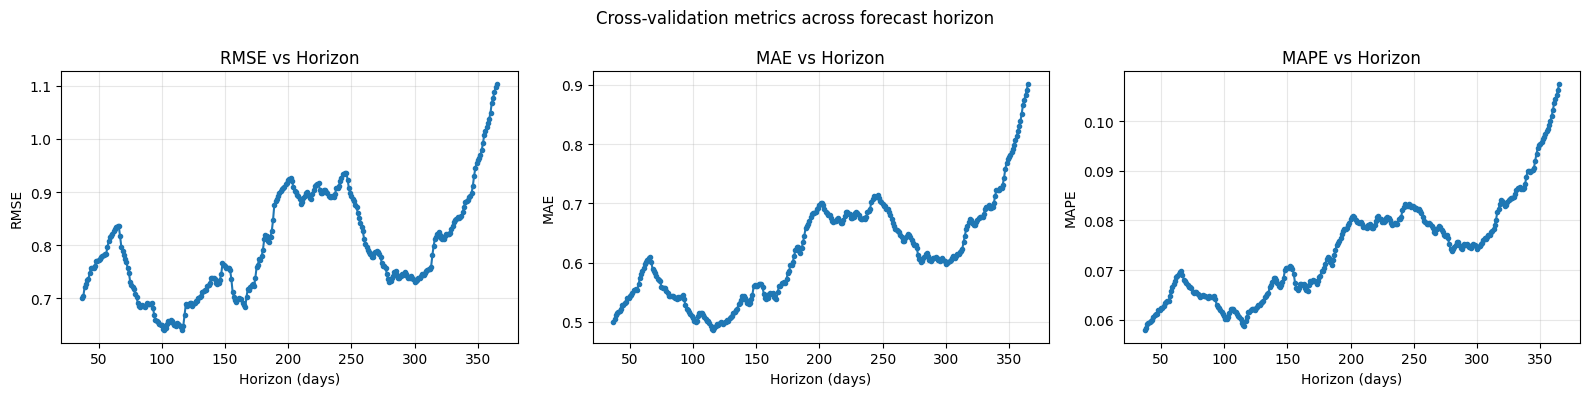

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, ["rmse", "mae", "mape"]):
    ax.plot(df_perf["horizon"].dt.days, df_perf[metric], marker="o", markersize=3)
    ax.set(xlabel="Horizon (days)", ylabel=metric.upper(), title=f"{metric.upper()} vs Horizon")
    ax.grid(True, alpha=0.3)
plt.suptitle("Cross-validation metrics across forecast horizon", fontsize=12)
plt.tight_layout()
plt.show()

/home/malam/.pyenv/versions/3.11.14/envs/spark3/lib/python3.11/site-packages/prophet/plot.py:546: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/home/malam/.pyenv/versions/3.11.14/envs/spark3/lib/python3.11/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


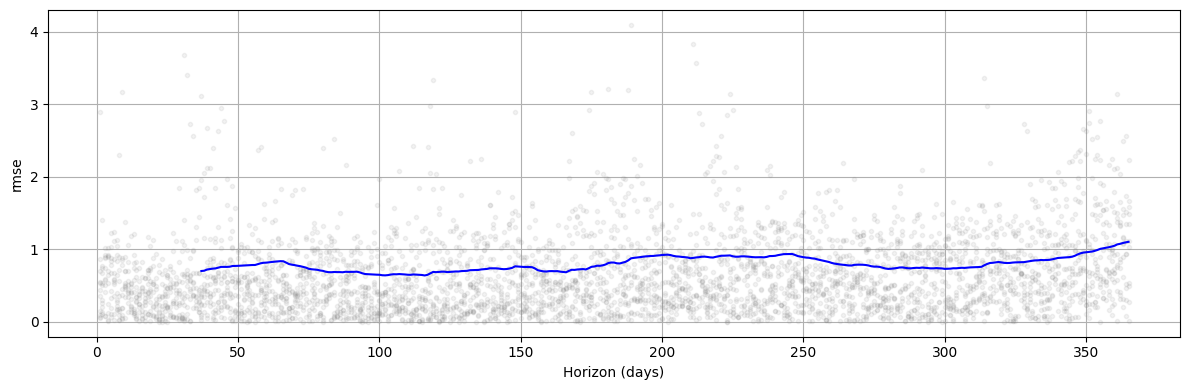

In [6]:
# Built-in helper
fig_cv = plot_cross_validation_metric(df_cv, metric="rmse")
fig_cv.set_size_inches(12, 4)
plt.tight_layout()
plt.show()

## 4. Hyperparameter Grid Search
The two most impactful parameters to tune:
- **`changepoint_prior_scale`** — trend flexibility
- **`seasonality_prior_scale`** — strength of seasonal fit
- **`seasonality_mode`** — additive vs multiplicative


In [7]:
param_grid = {
    "changepoint_prior_scale": [0.01, 0.05, 0.1, 0.5],
    "seasonality_prior_scale": [0.1,  1.0,  10.0],
    "seasonality_mode":        ["additive", "multiplicative"],
}

all_params = [dict(zip(param_grid, v)) for v in itertools.product(*param_grid.values())]
print(f"Total combinations: {len(all_params)}")

Total combinations: 24


In [8]:
results = []
for i, params in enumerate(all_params):
    m_tuned = Prophet(**params)
    m_tuned.fit(df)
    df_cv_t = cross_validation(m_tuned, initial="730 days", period="180 days",
                               horizon="365 days", parallel="processes", disable_tqdm=True)
    df_p = performance_metrics(df_cv_t, rolling_window=1)
    results.append({**params, "rmse": df_p["rmse"].values[0],
                               "mape": df_p["mape"].values[0]})
    print(f"[{i+1:02d}/{len(all_params)}] cps={params['changepoint_prior_scale']}  "
          f"sps={params['seasonality_prior_scale']}  mode={params['seasonality_mode']}  "
          f"→ RMSE={df_p['rmse'].values[0]:.4f}")

results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
print("\nTop 5 configurations:")
print(results_df.head(5).to_string(index=False))

08:18:54 - cmdstanpy - INFO - Chain [1] start processing


08:18:54 - cmdstanpy - INFO - Chain [1] done processing


08:18:54 - cmdstanpy - INFO - Chain [1] start processing


08:18:54 - cmdstanpy - INFO - Chain [1] start processing


08:18:55 - cmdstanpy - INFO - Chain [1] start processing


...

08:21:25 - cmdstanpy - INFO - Chain [1] start processing


08:21:26 - cmdstanpy - INFO - Chain [1] done processing


08:21:26 - cmdstanpy - INFO - Chain [1] done processing


08:21:27 - cmdstanpy - INFO - Chain [1] done processing


[24/24] cps=0.5  sps=10.0  mode=multiplicative  → RMSE=0.9217

Top 5 configurations:
 changepoint_prior_scale  seasonality_prior_scale seasonality_mode     rmse     mape
                    0.01                      1.0         additive 0.708763 0.062770
                    0.01                     10.0         additive 0.711608 0.063174
                    0.01                      1.0   multiplicative 0.711837 0.062444
                    0.01                     10.0   multiplicative 0.712079 0.062659
                    0.01                      0.1   multiplicative 0.712666 0.062897


## 5. Best Model — Refit & Evaluate

In [9]:
best_params = {k: results_df.iloc[0][k]
               for k in ["changepoint_prior_scale","seasonality_prior_scale","seasonality_mode"]}
print("Best params:", best_params)
print(f"Best RMSE  : {results_df.iloc[0]['rmse']:.4f}")
print(f"Best MAPE  : {results_df.iloc[0]['mape']:.4f}")

Best params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'additive'}
Best RMSE  : 0.7088
Best MAPE  : 0.0628


08:21:27 - cmdstanpy - INFO - Chain [1] start processing


08:21:28 - cmdstanpy - INFO - Chain [1] done processing


08:21:28 - cmdstanpy - INFO - Chain [1] start processing


08:21:28 - cmdstanpy - INFO - Chain [1] start processing


08:21:28 - cmdstanpy - INFO - Chain [1] start processing


...

08:21:29 - cmdstanpy - INFO - Chain [1] start processing


08:21:29 - cmdstanpy - INFO - Chain [1] start processing


08:21:30 - cmdstanpy - INFO - Chain [1] done processing


08:21:30 - cmdstanpy - INFO - Chain [1] done processing


08:21:30 - cmdstanpy - INFO - Chain [1] done processing


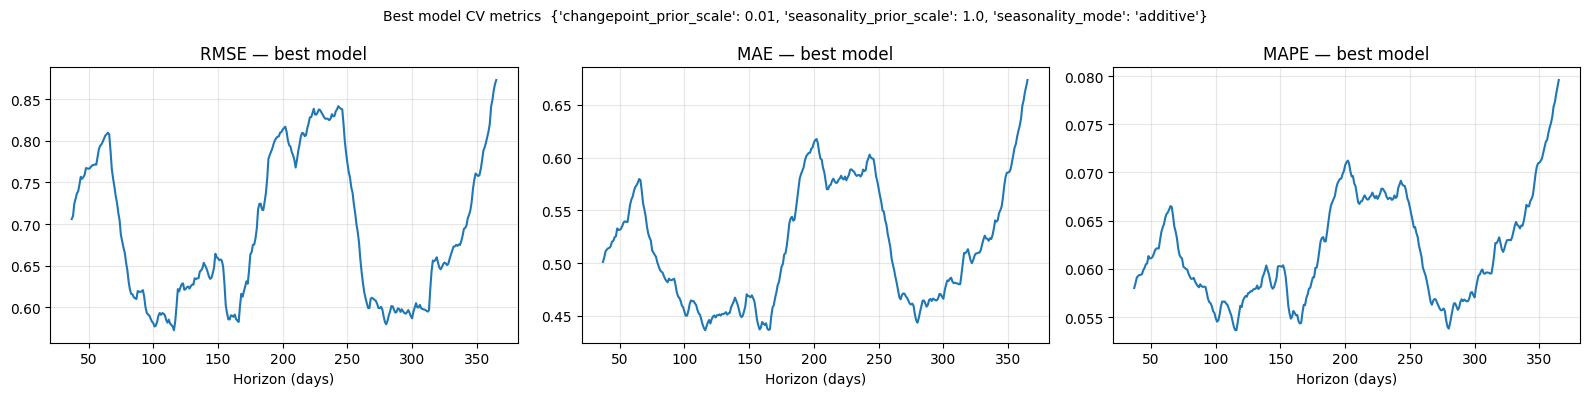

In [10]:
m_best = Prophet(**best_params, yearly_seasonality=True, weekly_seasonality=True)
m_best.fit(df)

df_cv_best = cross_validation(m_best, initial="730 days", period="180 days",
                              horizon="365 days", parallel="processes")
df_p_best  = performance_metrics(df_cv_best)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, ["rmse", "mae", "mape"]):
    ax.plot(df_p_best["horizon"].dt.days, df_p_best[metric])
    ax.set(xlabel="Horizon (days)", title=f"{metric.upper()} — best model")
    ax.grid(True, alpha=0.3)
plt.suptitle(f"Best model CV metrics  {best_params}", fontsize=10)
plt.tight_layout()
plt.show()

## 6. Serialize & Reload the Model

In [11]:
MODEL_PATH = "/tmp/prophet_best.pkl"

with open(MODEL_PATH, "wb") as f:
    pickle.dump(m_best, f)
print(f"Model saved → {MODEL_PATH}")

# Reload and predict
with open(MODEL_PATH, "rb") as f:
    m_loaded = pickle.load(f)

fc_loaded = m_loaded.predict(m_loaded.make_future_dataframe(periods=180))
print("Forecast from reloaded model (last 5 rows):")
print(fc_loaded[["ds","yhat","yhat_lower","yhat_upper"]].tail(5).to_string(index=False))

Model saved → /tmp/prophet_best.pkl


Forecast from reloaded model (last 5 rows):
        ds     yhat  yhat_lower  yhat_upper
2016-07-14 6.746877    6.165424    7.413085
2016-07-15 6.762770    6.105817    7.388098
2016-07-16 6.533617    5.892721    7.192175
2016-07-17 6.908456    6.302529    7.585643
2016-07-18 7.229919    6.597175    7.883653
